In [34]:
# To install nba_api:
# !pip install nba_api

In [35]:
import nba_api
from nba_api.stats.endpoints import leaguedashplayerstats, commonplayerinfo
import pandas as pd
import time
import numpy as np
from nba_api.stats.endpoints import commonplayerinfo
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
import joblib
import shap

In [36]:
# Phase 1: Pulling base and advanced stats from nba_api 

In [37]:
# Create dataFrame of stats for a season (base and advanced)
def get_season_stats(season, measure_type='Base'):
    stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense = measure_type,
        per_mode_detailed = 'PerGame'
    )
    return stats.get_data_frames()[0]

seasons = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']

# Lists of season dataframes (basic and advanced stats)
all_base = []
all_adv = []

# Each individual season stats data
for season in seasons:
    base = get_season_stats(season, 'Base')
    adv = get_season_stats(season, 'Advanced')

    base['SEASON'] = season
    adv['SEASON'] = season
    
    all_base.append(base)
    all_adv.append(adv)

base_df = pd.concat(all_base, ignore_index=True)
adv_df = pd.concat(all_adv, ignore_index=True)

base_df.to_csv('nba_base_stats.csv', index=False)
adv_df.to_csv('nba_advanced_stats.csv', index=False)


In [38]:
# Phase 2: Pairing consecutive seasons 
# First, merges base and advanced stats for one season
# Then, pairs back-to-back seasons so we can do year-by-year delta calculations

In [39]:
base_df = pd.read_csv('nba_base_stats.csv')
adv_df = pd.read_csv('nba_advanced_stats.csv')
 
# Columns to merge base and advanced stats on
key_cols = ['PLAYER_ID', 'SEASON']
 
# Drop overlapping columns from advanced stats dataframe (besides ID and season)
overlap_cols = [c for c in adv_df.columns if c in base_df.columns and c not in key_cols]
adv_df_trimmed = adv_df.drop(columns=overlap_cols)
 
merged = base_df.merge(adv_df_trimmed, on=key_cols, how='inner')
 
# Check for missing values in key columns
#key_stat_cols = ['PTS', 'AST', 'REB', 'MIN', 'GP']
#print("\nMissing values in key columns:")
#print(merged[key_stat_cols].isna().sum())
 
merged.to_csv('nba_merged_stats.csv', index=False)

# Convert year to int so it can be incremented(see below)
def season_to_year(season_str):
    return int(season_str.split('-')[0])
 
merged['SEASON_YEAR'] = merged['SEASON'].apply(season_to_year)
 
 
# "shifted" copy representing the previous season's data, re-labeled with the year it should be paired forward into.
prev = merged.copy()
prev['SEASON_YEAR'] = prev['SEASON_YEAR'] + 1  # shift forward by 1 year

# Suffix all stat columns so we know which side they came from after merge.
id_cols = ['PLAYER_ID', 'SEASON_YEAR']
prev_renamed = prev.rename(
    columns={c: f"{c}_prev" for c in prev.columns if c not in id_cols}
)
curr_renamed = merged.rename(
    columns={c: f"{c}_curr" for c in merged.columns if c not in id_cols}
)
 
# Inner join to ensure we have year-over-year data(meaning rookies are excluded)
pairs = prev_renamed.merge(curr_renamed, on=id_cols, how='inner')
 
print("\nGeneral structure of pairs dataframe structure(PPG as example stat):\n")
print(pairs[['PLAYER_ID','PLAYER_NAME_prev', 'PTS_prev', 'PTS_curr', 'SEASON_YEAR']].head(10))
pairs.to_csv('nba_season_pairs.csv', index=False)
print("\nSaved nba_season_pairs.csv")



General structure of pairs dataframe structure(PPG as example stat):

   PLAYER_ID  PLAYER_NAME_prev  PTS_prev  PTS_curr  SEASON_YEAR
0     203932      Aaron Gordon      16.0      14.4         2019
1    1628988     Aaron Holiday       5.9       9.5         2019
2    1627846       Abdel Nader       4.0       6.3         2019
3     201143        Al Horford      13.6      11.9         2019
4     202329   Al-Farouq Aminu       9.4       4.3         2019
5     202692        Alec Burks       8.8      15.0         2019
6    1627936       Alex Caruso       9.2       5.5         2019
7     203458          Alex Len      11.1       8.0         2019
8    1628035  Alfonzo McKinnie       4.7       4.6         2019
9    1628993     Alize Johnson       0.9       2.0         2019

Saved nba_season_pairs.csv


In [40]:
# Phase 3 - creating our target variable, breakout_score (a weighted composite of deltas)

In [41]:
pairs = pd.read_csv('nba_season_pairs.csv')

# Playing time filter: making sure we don't trust any too small sample sizes(must be equal or over 20 games played and 10 minutes per game for both seasons)
MIN_GP = 20
MIN_MPG = 10
pairs = pairs[(pairs['GP_prev'] >= MIN_GP) & (pairs['MIN_prev'] >= MIN_MPG) & (pairs['GP_curr'] >= MIN_GP) & (pairs['MIN_curr'] >= MIN_MPG)].copy()


# Calculate Game Score per game and add as column
def game_score(df, suffix):
    return (
        df[f'PTS{suffix}']
        + 0.4 * df[f'FGM{suffix}']
        - 0.7 * df[f'FGA{suffix}']
        - 0.4 * (df[f'FTA{suffix}'] - df[f'FTM{suffix}'])
        + 0.7 * df[f'OREB{suffix}']
        + 0.3 * df[f'DREB{suffix}']
        + df[f'STL{suffix}']
        + 0.7 * df[f'AST{suffix}']
        + 0.7 * df[f'BLK{suffix}']
        - 0.4 * df[f'PF{suffix}']
        - df[f'TOV{suffix}']
    )

pairs['GAME_SCORE_prev'] = game_score(pairs, '_prev')
pairs['GAME_SCORE_curr'] = game_score(pairs, '_curr')


# Find year-over-year deltas for all components of breakout score
pairs['delta_PIE'] = pairs['PIE_curr'] - pairs['PIE_prev']
pairs['delta_USG'] = pairs['USG_PCT_curr'] - pairs['USG_PCT_prev']
pairs['delta_TS'] = pairs['TS_PCT_curr'] - pairs['TS_PCT_prev']
pairs['delta_GAME_SCORE'] = pairs['GAME_SCORE_curr'] - pairs['GAME_SCORE_prev']




# Find Z-score for each stat in breakout score
pairs['z_PIE'] = (pairs['delta_PIE'] - pairs['delta_PIE'].mean())/(pairs['delta_PIE'].std())
pairs['z_USG'] = (pairs['delta_USG'] - pairs['delta_USG'].mean())/(pairs['delta_USG'].std())
pairs['z_TS'] = (pairs['delta_TS'] - pairs['delta_TS'].mean())/(pairs['delta_TS'].std())
pairs['z_GAME_SCORE'] = (pairs['delta_GAME_SCORE'] - pairs['delta_GAME_SCORE'].mean())/(pairs['delta_GAME_SCORE'].std())


# Calculate weighted breakout score and add as column
WEIGHTS = {
    'z_PIE': 0.35,
    'z_USG': 0.25,
    'z_TS': 0.20,
    'z_GAME_SCORE': 0.20,
}
 
pairs['breakout_score'] = (
    WEIGHTS['z_PIE'] * pairs['z_PIE']
    + WEIGHTS['z_USG'] * pairs['z_USG']
    + WEIGHTS['z_TS'] * pairs['z_TS']
    + WEIGHTS['z_GAME_SCORE'] * pairs['z_GAME_SCORE']
)

# Prior trajectory feature: pull all deltas from last season(assumes 0 if NaN) 
prior_trajectories = pairs.copy()[['PLAYER_ID','SEASON_curr', 'delta_PIE', 'delta_USG', 'delta_TS', 'delta_GAME_SCORE']]
prior_trajectories = prior_trajectories.rename(columns = {'delta_PIE' : 'prior_delta_PIE', 'delta_USG' : 'prior_delta_USG', 'delta_TS' : 'prior_delta_TS', 'delta_GAME_SCORE': 'prior_delta_GAME_SCORE'})
pairs = pd.merge(pairs, prior_trajectories, left_on=['PLAYER_ID', 'SEASON_prev'], right_on=['PLAYER_ID', 'SEASON_curr'])
pairs = pairs.fillna(0)
pairs = pairs.rename(columns = {'SEASON_curr_x' : 'SEASON_curr'}).drop(columns = 'SEASON_curr_y')
pairs = pairs.fillna(0)

print("\nComposite breakout_score distribution:")
print(pairs['breakout_score'].describe())
 
# Sanity check of top 15 existing breakout seasons in dataset 
top15 = pairs.sort_values('breakout_score', ascending=False)[
    ['PLAYER_NAME_curr', 'SEASON_prev', 'SEASON_curr', 'AGE_prev',
     'delta_PIE', 'delta_USG', 'delta_TS', 'delta_GAME_SCORE', 'breakout_score']
].head(15)
print("\nTop 15 breakout seasons (by composite score):")
print(top15.to_string(index=False))
 
# Bottom 10 (biggest decline) seasons 
bottom10 = pairs.sort_values('breakout_score', ascending=True)[
    ['PLAYER_NAME_curr', 'SEASON_prev', 'SEASON_curr', 'breakout_score']
].head(10)
print("\nBottom 10 (biggest declines):")
print(bottom10.to_string(index=False))
 
pairs.to_csv('nba_pairs_with_target.csv', index=False)
print(f"\nSaved nba_pairs_with_target.csv  ({len(pairs)} rows, {len(pairs.columns)} columns)")




Composite breakout_score distribution:
count    1300.000000
mean       -0.068914
std         0.753604
min        -2.454124
25%        -0.567193
50%        -0.080814
75%         0.419652
max         2.703266
Name: breakout_score, dtype: float64

Top 15 breakout seasons (by composite score):
       PLAYER_NAME_curr SEASON_prev SEASON_curr  AGE_prev  delta_PIE  delta_USG  delta_TS  delta_GAME_SCORE  breakout_score
        Lauri Markkanen     2021-22     2022-23      25.0      0.057      0.067     0.058              8.71        2.703266
         Damian Lillard     2021-22     2022-23      31.0      0.047      0.043     0.095              7.69        2.359502
         Quentin Grimes     2023-24     2024-25      24.0      0.046      0.063     0.079              6.26        2.339086
       Kenrich Williams     2019-20     2020-21      25.0      0.038      0.061     0.170              3.40        2.318547
              Ja Morant     2020-21     2021-22      21.0      0.050      0.063     0.03

In [42]:
# Phase 4: drawing supplementary data (such as position/experience data) to be used in the model
# Experience is often the biggest determining factor in a breakout
# Position work in accordance with age to predict a breakout (Centers break out at later ages compared to guards due to physical developments)

In [43]:
pairs = pd.read_csv('nba_pairs_with_target.csv')
 
# Get unique ID's (to limit API calls)
player_ids = pairs['PLAYER_ID'].unique()
print(f"Pulling info for {len(player_ids)} unique players...")
 
records = []
failed = []

# Draw draft year/experience and position data from API
for i, pid in enumerate(player_ids):
    try:
        info = commonplayerinfo.CommonPlayerInfo(player_id=pid)
        row = info.get_data_frames()[0].iloc[0]  # always one row
        records.append({
            'PLAYER_ID': pid,
            'POSITION': row['POSITION'],        # e.g. 'Guard', 'Forward-Guard'
            'DRAFT_YEAR': row['DRAFT_YEAR'],    # e.g. '2018' or 'Undrafted'
            'SEASON_EXP': row['SEASON_EXP'],    # years of NBA experience at time of pull
        })
        time.sleep(0.6)  # to stay under rate limit
    except Exception as e:
        print(f"  Failed for PLAYER_ID {pid}: {e}")
        failed.append(pid)
        time.sleep(1.0)  # longer pause after failures
 
player_info = pd.DataFrame(records)
print(f"\nSuccessfully pulled: {len(records)}")
print(f"Failed: {len(failed)}")
print(player_info.head(10))
 
player_info.to_csv('nba_player_info.csv', index=False)
print("\nSaved nba_player_info.csv")


Pulling info for 438 unique players...

Successfully pulled: 438
Failed: 0
   PLAYER_ID        POSITION DRAFT_YEAR  SEASON_EXP
0     203932         Forward       2014          12
1    1628988           Guard       2018           8
2    1627846         Forward       2016           5
3     201143  Center-Forward       2007          19
4     202692           Guard       2011          15
5    1627936           Guard  Undrafted           9
6     203458          Center       2013          13
7     203083          Center       2012          14
8       2738   Guard-Forward       2004          20
9     203952         Forward       2014          12

Saved nba_player_info.csv


In [44]:
# Phase 4 continued (manipulating supplementary data to work better with the model)

pairs = pd.read_csv('nba_pairs_with_target.csv')
player_info = pd.read_csv('nba_player_info.csv')

# Position + experience features

# Simplify position names; ex: Guard -> G
def simplify_position(pos):
    if pd.isna(pos) or pos == '':
        return 'Unknown'
    pos = str(pos).strip()
    if pos == 'Guard':
        return 'G'
    elif pos == 'Forward':
        return 'F'
    elif pos == 'Center':
        return 'C'
    elif 'Guard' in pos and 'Forward' in pos:
        return 'G-F'
    elif ('Forward' in pos and 'Center' in pos) or ('Center' in pos and 'Forward' in pos):
        return 'F-C'
    else:
        return 'Unknown'

player_info['POSITION'] = player_info['POSITION'].apply(simplify_position)

# int flag column to show if undrafted (more likely to breakout historically)
player_info['UNDRAFTED'] = (player_info['DRAFT_YEAR'] == 'Undrafted').astype(int)

player_info['DRAFT_YEAR'] = pd.to_numeric(player_info['DRAFT_YEAR'], errors='coerce')


print("Position distribution:")
print(player_info['POSITION'].value_counts())
print(f"\nUndrafted players: {player_info['UNDRAFTED'].sum()}")
 
# Merge position/experience data into pair df
pairs = pairs.merge(player_info[['PLAYER_ID', 'POSITION', 'UNDRAFTED', 'DRAFT_YEAR']],
                    on='PLAYER_ID', how='left')

# Calculate years in league(for drafted players) for a given year
pairs['YEARS_IN_LEAGUE_prev'] = pairs['SEASON_YEAR'] - 1 - pairs['DRAFT_YEAR']

# Give undrafted players an estimate on years in league(22 is the average age of undrafted players entering the league)
undrafted_players = pairs['UNDRAFTED'] == 1
pairs.loc[undrafted_players, 'YEARS_IN_LEAGUE_prev'] = (pairs.loc[undrafted_players, 'AGE_prev'] - 22)

# Ensure years in league accounts for draft edge cases/undrafted players younger than 22
pairs['YEARS_IN_LEAGUE_prev'] = pairs['YEARS_IN_LEAGUE_prev'].clip(lower = 0)

position_dummies = pd.get_dummies(pairs['POSITION'], prefix='POS').astype(int)
print(position_dummies)
pairs = pd.concat([pairs, position_dummies], axis=1)
 

print("\nSample of new columns:")
check_cols = ['PLAYER_NAME_prev', 'SEASON_prev', 'AGE_prev', 'POSITION',
              'YEARS_IN_LEAGUE_prev', 'UNDRAFTED']
print(pairs[check_cols].head(15).to_string(index=False))
 
 
pairs.to_csv('nba_pairs_phase4.csv', index=False)
print(f"\nSaved nba_pairs_phase4.csv  ({len(pairs)} rows, {len(pairs.columns)} columns)")


Position distribution:
POSITION
G      165
F      120
G-F     65
F-C     54
C       34
Name: count, dtype: int64

Undrafted players: 65
      POS_C  POS_F  POS_F-C  POS_G  POS_G-F
0         0      1        0      0        0
1         0      0        0      1        0
2         0      1        0      0        0
3         0      0        1      0        0
4         0      0        0      1        0
...     ...    ...      ...    ...      ...
1295      0      0        1      0        0
1296      0      0        1      0        0
1297      0      0        0      1        0
1298      0      1        0      0        0
1299      0      1        0      0        0

[1300 rows x 5 columns]

Sample of new columns:
PLAYER_NAME_prev SEASON_prev  AGE_prev POSITION  YEARS_IN_LEAGUE_prev  UNDRAFTED
    Aaron Gordon     2019-20      24.0        F                   5.0          0
   Aaron Holiday     2019-20      23.0        G                   1.0          0
     Abdel Nader     2019-20      26.0      

In [45]:
# Phase 5 - feature engineering
# Only "_prev" data is used as the prior season is used to inform the model on the next season's breakout likeliness

In [46]:
pairs = pd.read_csv('nba_pairs_phase4.csv')
 
 
features = pd.DataFrame()
features['PLAYER_ID'] = pairs['PLAYER_ID']
features['PLAYER_NAME'] = pairs['PLAYER_NAME_prev']
features['SEASON_prev'] = pairs['SEASON_prev']
features['SEASON_curr'] = pairs['SEASON_curr']
features['breakout_score'] = pairs['breakout_score']  # target variable
 
# Player context features
 
features['AGE'] = pairs['AGE_prev']
 
# Age affects breakout potential non-linearly, squaring to help the model pick up on this
features['AGE_SQ'] = pairs['AGE_prev'] ** 2

features['YEARS_IN_LEAGUE'] = pairs['YEARS_IN_LEAGUE_prev']
 
# Flag to track if player is within ideal age/experience range to breakout (between 22 and 25, between 1 and 4 prior years in the league)
features['IN_BREAKOUT_WINDOW'] = (
    (pairs['AGE_prev'] >= 22) &
    (pairs['AGE_prev'] <= 25) &
    (pairs['YEARS_IN_LEAGUE_prev'] >= 1) &
    (pairs['YEARS_IN_LEAGUE_prev'] <= 4)
).astype(int)


features['UNDRAFTED'] = pairs['UNDRAFTED']
 
# Position dummies 
for col in ['POS_G', 'POS_F', 'POS_C', 'POS_G-F', 'POS_F-C']:
    features[col] = pairs[col]
 
# Volume/role features 

features['MIN_PG'] = pairs['MIN_prev']
features['GP'] = pairs['GP_prev']
features['USG_PCT'] = pairs['USG_PCT_prev']
 
# Flag to show low minutes (higher opportunity upside if more minutes are given next season)
features['LOW_MINUTES'] = (pairs['MIN_prev'] < 20).astype(int)
 
# Efficiency features

features['TS_PCT'] = pairs['TS_PCT_prev']
features['EFG_PCT'] = pairs['EFG_PCT_prev']
features['PIE'] = pairs['PIE_prev']
 
# Efficiency gap — difference between USG% and PIE. A large gap indicates inefficiency but high opportunity, and thus higher upside
# Scale USG to 0-1 to make it comparable to PIE (which is already 0-1).
features['EFFICIENCY_GAP'] = (pairs['USG_PCT_prev'] / 100) - pairs['PIE_prev']


# Basic box score stats
features['PTS_PG'] = pairs['PTS_prev']
features['AST_PG'] = pairs['AST_prev']
features['REB_PG'] = pairs['REB_prev']
features['STL_PG'] = pairs['STL_prev']
features['BLK_PG'] = pairs['BLK_prev']
features['TOV_PG'] = pairs['TOV_prev']

# Prior trajectory features

features['PRIOR_DELTA_PIE'] = pairs['prior_delta_PIE']
features['PRIOR_DELTA_USG'] = pairs['prior_delta_USG']
features['PRIOR_DELTA_TS'] = pairs['prior_delta_TS']
features['PRIOR_DELTA_GAME_SCORE'] = pairs['prior_delta_GAME_SCORE']


print("Feature list:")
print([c for c in features.columns if c not in ['PLAYER_ID','PLAYER_NAME','SEASON_prev','SEASON_curr','breakout_score']])
 
print("\nSample rows:")
print(features[['PLAYER_NAME','SEASON_prev','AGE','YEARS_IN_LEAGUE',
                'IN_BREAKOUT_WINDOW','MIN_PG','USG_PCT','TS_PCT',
                'EFFICIENCY_GAP','breakout_score']].head(10).to_string(index=False))
 

features.to_csv('nba_features.csv', index=False)
print(f"\nSaved nba_features.csv")


Feature list:
['AGE', 'AGE_SQ', 'YEARS_IN_LEAGUE', 'IN_BREAKOUT_WINDOW', 'UNDRAFTED', 'POS_G', 'POS_F', 'POS_C', 'POS_G-F', 'POS_F-C', 'MIN_PG', 'GP', 'USG_PCT', 'LOW_MINUTES', 'TS_PCT', 'EFG_PCT', 'PIE', 'EFFICIENCY_GAP', 'PTS_PG', 'AST_PG', 'REB_PG', 'STL_PG', 'BLK_PG', 'TOV_PG', 'PRIOR_DELTA_PIE', 'PRIOR_DELTA_USG', 'PRIOR_DELTA_TS', 'PRIOR_DELTA_GAME_SCORE']

Sample rows:
   PLAYER_NAME SEASON_prev  AGE  YEARS_IN_LEAGUE  IN_BREAKOUT_WINDOW  MIN_PG  USG_PCT  TS_PCT  EFFICIENCY_GAP  breakout_score
  Aaron Gordon     2019-20 24.0              5.0                   0    32.5    0.205   0.516        -0.10195       -0.205324
 Aaron Holiday     2019-20 23.0              1.0                   1    24.5    0.182   0.521        -0.07618       -0.623132
   Abdel Nader     2019-20 26.0              3.0                   0    15.8    0.164   0.591        -0.07036        0.697787
    Al Horford     2019-20 34.0             12.0                   0    30.2    0.173   0.536        -0.11027        

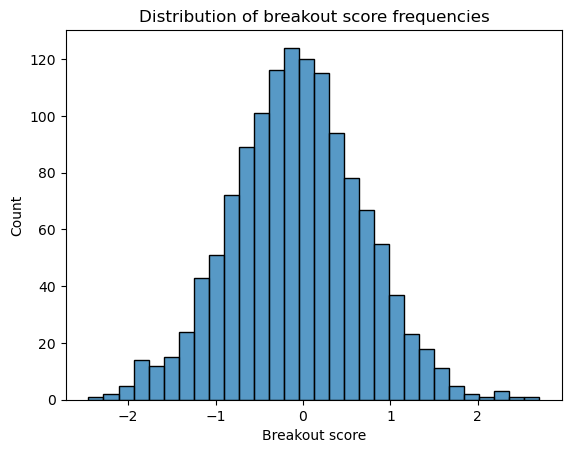

In [47]:
# Phase 6 - exploratory analysis
features = pd.read_csv('nba_features.csv')
sns.histplot(features['breakout_score'], bins = 30)
plt.title('Distribution of breakout score frequencies')
plt.xlabel('Breakout score')
plt.ylabel('Count')
plt.show()

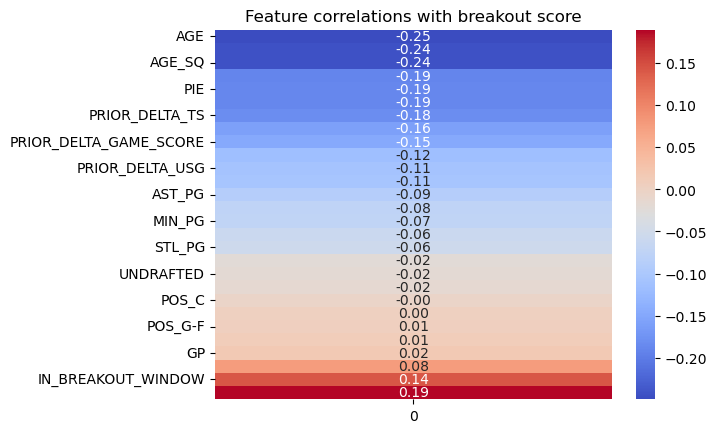

In [48]:
features = pd.read_csv('nba_features.csv')

# Drop irrelevant columns 
exclude = ['PLAYER_ID', 'breakout_score']
features_numeric = features.select_dtypes(include='number').drop(columns=exclude)
correlations = features_numeric.corrwith(features['breakout_score']).sort_values()
sns.heatmap(correlations.to_frame(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Feature correlations with breakout score')


plt.show()

In [49]:
# Phase 7 - Baseline(linear regression) model
# Used as a comparison to base the results of the decision tree model later on
# Trained on 2021-22, 2022-23 seasons, tested with 2023-24 season to predicit 2024-25 breakouts

In [57]:
from sklearn.metrics import mean_absolute_error, r2_score

features = pd.read_csv('nba_features.csv')

# Exclude identity columns and target variable
exclude_cols = ['PLAYER_ID', 'PLAYER_NAME', 'SEASON_prev', 'SEASON_curr', 'breakout_score']


x_train = features[features['SEASON_prev'].isin(['2021-22','2022-23'])]
y_train = x_train['breakout_score']
x_train = x_train.drop(columns = exclude_cols)
x_test = features[features['SEASON_prev'].isin(['2023-24'])]
y_test = x_test['breakout_score']
x_test = x_test.drop(columns = exclude_cols)

sk_model = LinearRegression()
sk_model.fit(x_train, y_train)
sk_y_prediction = sk_model.predict(x_test)


sk_mae = mean_absolute_error(y_test, sk_y_prediction)
print(f"Mean Absolute Error: {sk_mae}")

sk_r2score = r2_score(y_test, sk_y_prediction)
print(f"R-squared score: {sk_r2score}")

sk_results = pd.DataFrame({
    'PLAYER_NAME': features[features['SEASON_prev'] == '2023-24']['PLAYER_NAME'].values,
    'ACTUAL': y_test.values,
    'PREDICTED': sk_y_prediction
}).sort_values('PREDICTED', ascending=False)

print("\nSample comparisons: ")
print(sk_results.head(5))



(528, 33)
Mean Absolute Error: 0.5437458026957714
R-squared score: -0.014571612464639339

Sample comparisons: 
      PLAYER_NAME    ACTUAL  PREDICTED
146     KJ Martin  0.334743   0.982282
100       JT Thor  0.309865   0.816084
161     Kris Dunn -0.244588   0.762797
205  Ochai Agbaji  1.595953   0.708281
45    Cory Joseph  1.251966   0.706082


In [51]:
# Phase 8 - XGBoost(decision tree) model
# A more nuanced model that will do a better job encapsulating the non-linear effects of stats like age and relationships between features
# Trained/tested with same data as linear regression

Mean Absolute Error: 0.5221856014169368
R-squared score: 0.03152803797868042
          PLAYER_NAME    ACTUAL  PREDICTED
45        Cory Joseph  1.251966   0.920440
25     Brandon Boston  1.106066   0.886904
213       Patty Mills  0.488733   0.675841
127     Jeremy Sochan  0.738577   0.644323
32        Cam Reddish -0.549604   0.593844
161         Kris Dunn -0.244588   0.588284
139       Josh Giddey  0.470628   0.506725
101  Jabari Smith Jr. -0.424737   0.496619
30      Caleb Houstan  0.242173   0.492092
209    Paolo Banchero  0.950134   0.489198
         PLAYER_NAME    ACTUAL  PREDICTED
235   T.J. McConnell -0.763652  -0.656667
55    DeAndre Jordan -0.002406  -0.661797
85    Gary Payton II  0.893130  -0.672460
74    Draymond Green -0.597392  -0.741063
113      Jalen Smith -0.228814  -0.743000
6        Alex Caruso -0.143272  -0.763175
176      Luke Kornet -0.079475  -0.832220
191    Moritz Wagner  0.818827  -0.854854
76   Duncan Robinson -0.259495  -1.037896
157       Kevin Love -1.235959

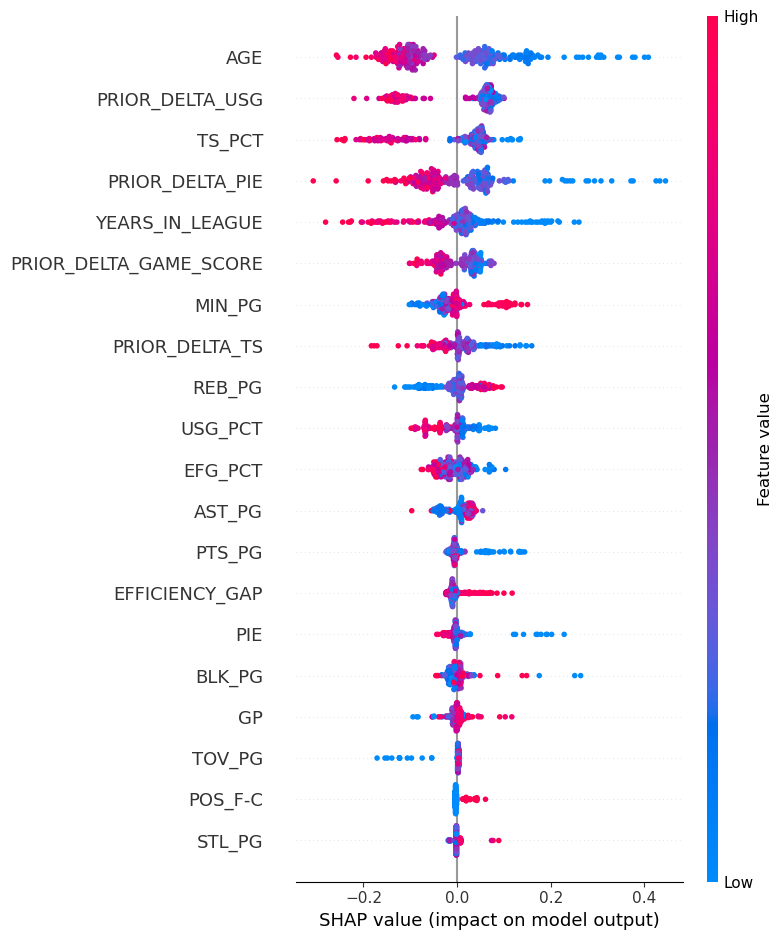

['xg_model.pkl']

In [52]:
xg_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state = 42
)
xg_model.fit(x_train, y_train)
xg_y_prediction = xg_model.predict(x_test)

xg_results = pd.DataFrame({
    'PLAYER_NAME': features[features['SEASON_prev'] == '2023-24']['PLAYER_NAME'].values,
    'ACTUAL': y_test.values,
    'PREDICTED': xg_y_prediction
}).sort_values('PREDICTED', ascending=False)

xg_mae = mean_absolute_error(y_test, xg_y_prediction)
print(f"Mean Absolute Error: {xg_mae}")

xg_r2score = r2_score(y_test, xg_y_prediction)
print(f"R-squared score: {xg_r2score}")
print(xg_results.head(10))
print(xg_results.tail(10))

# SHAP to explain the xgboost model's decision making
explainer = shap.TreeExplainer(xg_model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)

joblib.dump(xg_model, 'xg_model.pkl')

In [53]:
# Phase 9 - 2026-27 season predictions
# Similar pipeline as earlier for 2025-2026 stats, mainly just no season pairing & no calculating breakout score
# Note that variables names like current_pairs and recent_features are functionally the same as pairs and features respectively, just indicating 2025-26 data

In [54]:
def get_season_stats(season, measure_type='Base'):
    stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        season_type_all_star='Regular Season',
        measure_type_detailed_defense = measure_type,
        per_mode_detailed = 'PerGame'
    )
    return stats.get_data_frames()[0]

seasons = ['2025-26']

# Lists of season dataframes (basic and advanced stats)
all_base = []
all_adv = []

for season in seasons:
    base = get_season_stats(season, 'Base')
    adv = get_season_stats(season, 'Advanced')

    # Create season column in each dataframe
    base['SEASON'] = season
    adv['SEASON'] = season
    
    all_base.append(base)
    all_adv.append(adv)

base_df = pd.concat(all_base, ignore_index=True)
adv_df = pd.concat(all_adv, ignore_index=True)

base_df.to_csv('recent_base_stats.csv', index=False)
adv_df.to_csv('recent_advanced_stats.csv', index=False)

def game_score(df, suffix):
    return (
        df[f'PTS{suffix}']
        + 0.4 * df[f'FGM{suffix}']
        - 0.7 * df[f'FGA{suffix}']
        - 0.4 * (df[f'FTA{suffix}'] - df[f'FTM{suffix}'])
        + 0.7 * df[f'OREB{suffix}']
        + 0.3 * df[f'DREB{suffix}']
        + df[f'STL{suffix}']
        + 0.7 * df[f'AST{suffix}']
        + 0.7 * df[f'BLK{suffix}']
        - 0.4 * df[f'PF{suffix}']
        - df[f'TOV{suffix}']
    )


# Simplify position names; ex: Guard -> G
def simplify_position(pos):
    if pd.isna(pos) or pos == '':
        return 'Unknown'
    pos = str(pos).strip()
    if pos == 'Guard':
        return 'G'
    elif pos == 'Forward':
        return 'F'
    elif pos == 'Center':
        return 'C'
    elif 'Guard' in pos and 'Forward' in pos:
        return 'G-F'
    elif ('Forward' in pos and 'Center' in pos) or ('Center' in pos and 'Forward' in pos):
        return 'F-C'
    else:
        return 'Unknown'

recent_base_stats = pd.read_csv('recent_base_stats.csv')
recent_adv_stats = pd.read_csv('recent_advanced_stats.csv')

# Columns to merge base and advanced stats on
key_cols = ['PLAYER_ID', 'SEASON']
 
# Drop overlapping columns from advanced stats dataframe (besides ID and season)
overlap_cols = [c for c in recent_adv_stats.columns if c in recent_base_stats.columns and c not in key_cols]
adv_df_trimmed = recent_adv_stats.drop(columns=overlap_cols)
 
merged = recent_base_stats.merge(adv_df_trimmed, on=key_cols, how='inner')
 

# Check for missing values in key columns
key_stat_cols = ['PTS', 'AST', 'REB', 'MIN', 'GP']


# Convert year to int that can be incremented
def season_to_year(season_str):
    return int(season_str.split('-')[0])
 
merged['SEASON_YEAR'] = merged['SEASON'].apply(season_to_year)


previous_merged_stats = pd.read_csv('nba_merged_stats.csv')
prev = previous_merged_stats[previous_merged_stats['SEASON'] == '2024-25'].copy()

prev['SEASON_YEAR'] = prev['SEASON'].apply(season_to_year)

# Prefix stat columns to differentiate seasons stats are from

id_cols = ['PLAYER_ID', 'SEASON_YEAR']
prev_renamed = prev.rename(
    columns={c: f"{c}_prev" for c in prev.columns if c not in id_cols}
)
curr_renamed = merged.rename(
    columns={c: f"{c}_curr" for c in merged.columns if c not in id_cols}
)

current_pairs = prev_renamed.merge(curr_renamed, on = 'PLAYER_ID', how = 'inner')



current_pairs['GAME_SCORE_prev'] = game_score(current_pairs, '_prev')
current_pairs['GAME_SCORE_curr'] = game_score(current_pairs, '_curr')


# Find deltas for all components of composite score

current_pairs['delta_PIE'] = current_pairs['PIE_curr'] - current_pairs['PIE_prev']
current_pairs['delta_USG'] = current_pairs['USG_PCT_curr'] - current_pairs['USG_PCT_prev']
current_pairs['delta_TS'] = current_pairs['TS_PCT_curr'] - current_pairs['TS_PCT_prev']
current_pairs['delta_GAME_SCORE'] = current_pairs['GAME_SCORE_curr'] - current_pairs['GAME_SCORE_prev']


# Merge player info (age, position, draft year) features into current df
player_info = pd.read_csv('nba_player_info.csv')


# Position + experience features

player_info['POSITION'] = player_info['POSITION'].apply(simplify_position)

# int flag column to show if undrafted (more likely to breakout historically)
player_info['UNDRAFTED'] = (player_info['DRAFT_YEAR'] == 'Undrafted').astype(int)

player_info['DRAFT_YEAR'] = pd.to_numeric(player_info['DRAFT_YEAR'], errors='coerce')


# Merge position/experience data into pair df
current_pairs = current_pairs.merge(player_info[['PLAYER_ID', 'POSITION', 'UNDRAFTED', 'DRAFT_YEAR']],
                    on='PLAYER_ID', how='left')

# Calculate years in league(for drafted players) for a given year
current_pairs['YEARS_IN_LEAGUE_prev'] = 2025 - 1 - current_pairs['DRAFT_YEAR']

# Give undrafted players an estimate on years in league(22 is the average age of undrafted players entering the league)
undrafted_players = current_pairs['UNDRAFTED'] == 1
current_pairs.loc[undrafted_players, 'YEARS_IN_LEAGUE_prev'] = (current_pairs.loc[undrafted_players, 'AGE_prev'] - 22)

# Ensure years in league accounts for draft edge cases/undrafted players younger than 22
current_pairs['YEARS_IN_LEAGUE_prev'] = current_pairs['YEARS_IN_LEAGUE_prev'].clip(lower = 0)

position_dummies = pd.get_dummies(current_pairs['POSITION'], prefix='POS').astype(int)
current_pairs = pd.concat([current_pairs, position_dummies], axis=1)

# Feature engineering for 2025-2026 data
recent_features = pd.DataFrame()


recent_features['PLAYER_ID'] = current_pairs['PLAYER_ID']
recent_features['PLAYER_NAME'] = current_pairs['PLAYER_NAME_prev']
recent_features['SEASON_prev'] = current_pairs['SEASON_prev']
recent_features['SEASON_curr'] = current_pairs['SEASON_curr']

recent_features['AGE'] = current_pairs['AGE_prev']
recent_features['AGE_SQ'] = current_pairs['AGE_prev'] ** 2
recent_features['YEARS_IN_LEAGUE'] = current_pairs['YEARS_IN_LEAGUE_prev']

recent_features['IN_BREAKOUT_WINDOW'] = (
    (current_pairs['AGE_prev'] >= 22) &
    (current_pairs['AGE_prev'] <= 25) &
    (current_pairs['YEARS_IN_LEAGUE_prev'] >= 1) &
    (current_pairs['YEARS_IN_LEAGUE_prev'] <= 4)
).astype(int)

recent_features['UNDRAFTED'] = current_pairs['UNDRAFTED']

for col in ['POS_G', 'POS_F', 'POS_C', 'POS_G-F', 'POS_F-C']:
    recent_features[col] = current_pairs[col] if col in current_pairs.columns else 0


# Usage/min stats

recent_features['MIN_PG'] = current_pairs['MIN_prev']
recent_features['GP'] = current_pairs['GP_prev']

# Filter out low games played/mins played candidates due to small sample size, along with players 35+(as players this age typically are very unlikely to break out)
recent_features = recent_features[
    (current_pairs['GP_prev'] >= 20) & 
    (current_pairs['MIN_prev'] >= 10) &
    (current_pairs['AGE_prev'] <= 35)
].copy()

recent_features['USG_PCT'] = current_pairs['USG_PCT_prev']
recent_features['LOW_MINUTES'] = (current_pairs['MIN_prev'] < 20).astype(int)
recent_features['TS_PCT'] = current_pairs['TS_PCT_prev']
recent_features['EFG_PCT'] = current_pairs['EFG_PCT_prev']
recent_features['PIE'] = current_pairs['PIE_prev']
recent_features['EFFICIENCY_GAP'] = (current_pairs['USG_PCT_prev'] / 100) - current_pairs['PIE_prev']
 
# Box score stats 
recent_features['PTS_PG'] = current_pairs['PTS_prev']
recent_features['AST_PG'] = current_pairs['AST_prev']
recent_features['REB_PG'] = current_pairs['REB_prev']
recent_features['STL_PG'] = current_pairs['STL_prev']
recent_features['BLK_PG'] = current_pairs['BLK_prev']
recent_features['TOV_PG'] = current_pairs['TOV_prev']


# Prior trajectory features

recent_features['PRIOR_DELTA_PIE'] = current_pairs['delta_PIE']
recent_features['PRIOR_DELTA_USG'] = current_pairs['delta_USG']
recent_features['PRIOR_DELTA_TS'] = current_pairs['delta_TS']
recent_features['PRIOR_DELTA_GAME_SCORE'] = current_pairs['delta_GAME_SCORE']


# Rookies/players without player info stats get dropped
recent_features['YEARS_IN_LEAGUE'] = recent_features['YEARS_IN_LEAGUE'].fillna(0)
recent_features['UNDRAFTED'] = recent_features['UNDRAFTED'].fillna(0)
recent_features['IN_BREAKOUT_WINDOW'] = recent_features['IN_BREAKOUT_WINDOW'].fillna(0)

recent_features.to_csv('recent_features.csv', index = False)

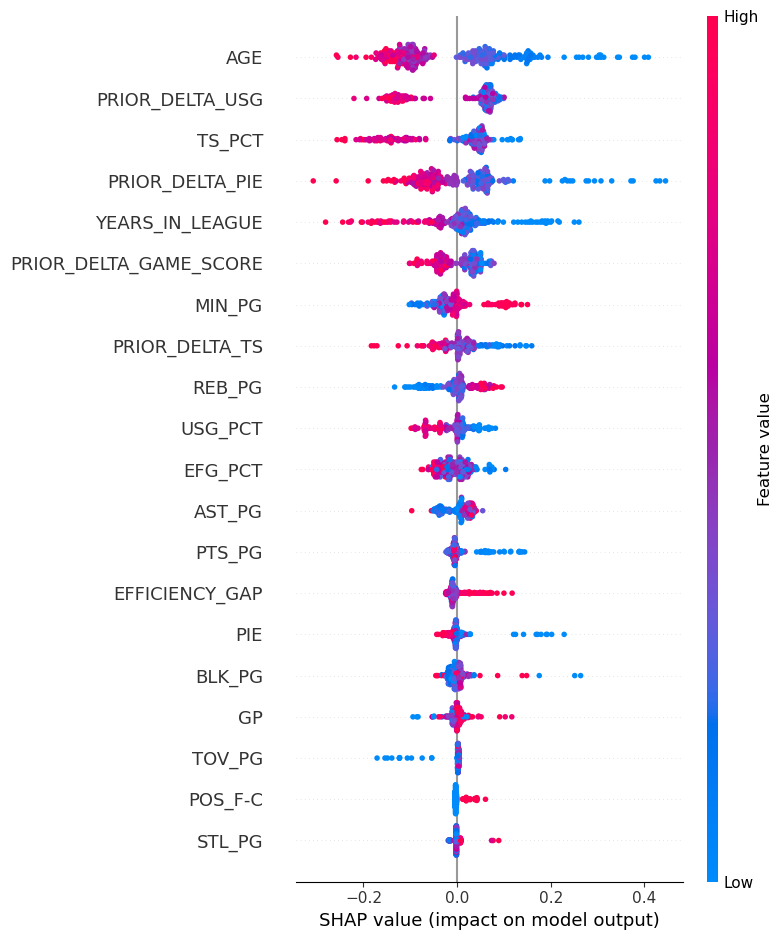

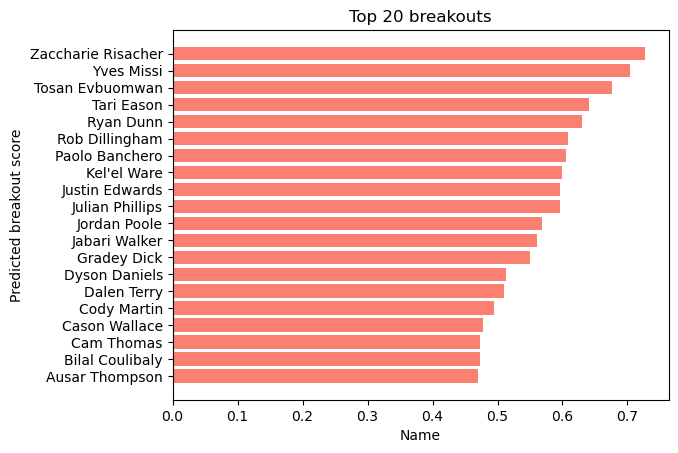

In [55]:
# Running the model on the 2025-26 data to predict 2026-27 breakouts

recent_features = pd.read_csv('recent_features.csv')

x_prediction = recent_features.copy().drop(columns = ['PLAYER_ID', 'PLAYER_NAME', 'SEASON_prev', 'SEASON_curr'])



next_season_prediction = xg_model.predict(x_prediction)

results = pd.DataFrame({'PLAYER_NAME': recent_features['PLAYER_NAME'], 'PREDICTED_BREAKOUT_SCORE': next_season_prediction}).sort_values('PREDICTED_BREAKOUT_SCORE', ascending = False)

# SHAP to explain the xgboost model's decision making
explainer = shap.TreeExplainer(xg_model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)

# Show top 20 predicted breakouts
plt.bar

x_data = results['PLAYER_NAME'].head(20).sort_values(ascending = True)
y_data = results['PREDICTED_BREAKOUT_SCORE'].head(20).sort_values(ascending = True)

plt.barh(x_data, y_data, color='salmon')
plt.xlabel('Name')
plt.ylabel('Predicted breakout score')
plt.title('Top 20 breakouts')
plt.show
results.to_csv('nba_2027_breakout_predictions.csv', index=False)
